<a href="https://colab.research.google.com/github/rexwotan-A01840088/Ciencia-y-Analitica-de-datos/blob/main/Actividad8RLineal_Equipo_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Rex Wotan Dominguez Chang
*   MATRÍCULA: A01840088
*   NOMBRE: Sofía Donlucas Bañuelos
*   MATRÍCULA: A01655565
*   NOMBRE: Gerardo Duarte Ceballos
*   MATRÍCULA: A01273069
*   NOMBRE: Miguel Angel Duran Betancourt
*   MATRÍCULA: A01797974

En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

* `carat`: Peso del diamante en quilates
* `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
* `color`: Color del diamante, de D (mejor) a J (peor)
* `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
* `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
* `table`: Ancho de la tabla del diamante como porcentaje de x
* `x`: Longitud en mm
* `y`: Ancho en mm
* `z`: Profundidad en mm
* `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o *target*

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score

1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.

In [2]:
# === 1. Cargar los datos del archivo ===
PATH = "diamonds_dataset.csv"
diamonds_df = pd.read_csv(PATH)

# Mostrar las primeras filas para confirmar la carga
print("Dimensiones del dataset:", diamonds_df.shape)
display(diamonds_df.head())

# === 2. Resumen general del DataFrame ===
print("\n--- Información general del DataFrame ---")
diamonds_df.info()

# Identificar columnas numéricas y categóricas
num_cols = diamonds_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = diamonds_df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nColumnas numéricas ({len(num_cols)}): {num_cols}")
print(f"Columnas categóricas ({len(cat_cols)}): {cat_cols}")

# === 3. Cantidad de valores únicos por columna ===
print("\n--- Valores únicos por columna ---")
unique_counts = diamonds_df.nunique().sort_values(ascending=False)
display(unique_counts)

# === 4. Verificar valores faltantes ===
print("\n--- Porcentaje de valores faltantes por columna ---")
missing_pct = diamonds_df.isna().mean().sort_values(ascending=False) * 100
display(missing_pct)

# === 5. Verificar y eliminar duplicados ===
dups = diamonds_df.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {dups}")

if dups > 0:
    diamonds_df = diamonds_df.drop_duplicates().reset_index(drop=True)
    print("Duplicados eliminados. Nuevo tamaño del DataFrame:", diamonds_df.shape)
else:
    print("No se encontraron duplicados. Tamaño del DataFrame:", diamonds_df.shape)

# Confirmar reinicio de índice
print("\nPrimeras filas después de limpiar duplicados:")
display(diamonds_df.head())

Dimensiones del dataset: (53936, 10)


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335



--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53936 entries, 0 to 53935
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53936 non-null  float64
 1   cut      53936 non-null  object 
 2   color    53936 non-null  object 
 3   clarity  53936 non-null  object 
 4   depth    53936 non-null  float64
 5   table    53936 non-null  float64
 6   x        53936 non-null  float64
 7   y        53936 non-null  float64
 8   z        53936 non-null  float64
 9   price    53936 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB

Columnas numéricas (7): ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
Columnas categóricas (3): ['cut', 'color', 'clarity']

--- Valores únicos por columna ---


,0
price,11600
x,551
y,551
z,372
carat,271
depth,184
table,127
clarity,8
color,7
cut,5



--- Porcentaje de valores faltantes por columna ---


,0
carat,0.0
cut,0.0
color,0.0
clarity,0.0
depth,0.0
table,0.0
x,0.0
y,0.0
z,0.0
price,0.0



Registros duplicados encontrados: 146
Duplicados eliminados. Nuevo tamaño del DataFrame: (53790, 10)

Primeras filas después de limpiar duplicados:


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
* Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.


--- Estadísticas descriptivas: variables numéricas ---


,count,mean,std,min,25%,50%,75%,max
carat,53790.0,0.797567,0.472696,0.2,0.40,0.70,1.04,4.50
depth,53790.0,61.748007,1.429789,43.0,61.00,61.80,62.50,79.00
table,53790.0,57.457938,2.233613,43.0,56.00,57.00,59.00,95.00
x,53790.0,5.730916,1.120187,0.0,4.71,5.70,6.54,10.23
y,53790.0,5.734363,1.140741,0.0,4.72,5.71,6.54,58.90
z,53790.0,3.538524,0.704699,0.0,2.91,3.53,4.03,31.80
price,53790.0,3932.165793,3986.884865,326.0,951.00,2401.00,5324.75,18823.00



--- Tablas de frecuencia: variables categóricas ---

Frecuencia de cut:


,frecuencia,porcentaje (%)
cut,,
Ideal,21488,39.95
Premium,13748,25.56
Very Good,12066,22.43
Good,4891,9.09
Fair,1597,2.97



Frecuencia de color:


,frecuencia,porcentaje (%)
color,,
G,11262,20.94
E,9776,18.17
F,9520,17.70
H,8272,15.38
D,6754,12.56
I,5405,10.05
J,2801,5.21



Frecuencia de clarity:


,frecuencia,porcentaje (%)
clarity,,
SI1,13032,24.23
VS2,12229,22.73
SI2,9148,17.01
VS1,8156,15.16
VVS2,5056,9.40
VVS1,3647,6.78
IF,1784,3.32
I1,738,1.37



--- Histogramas de variables numéricas ---


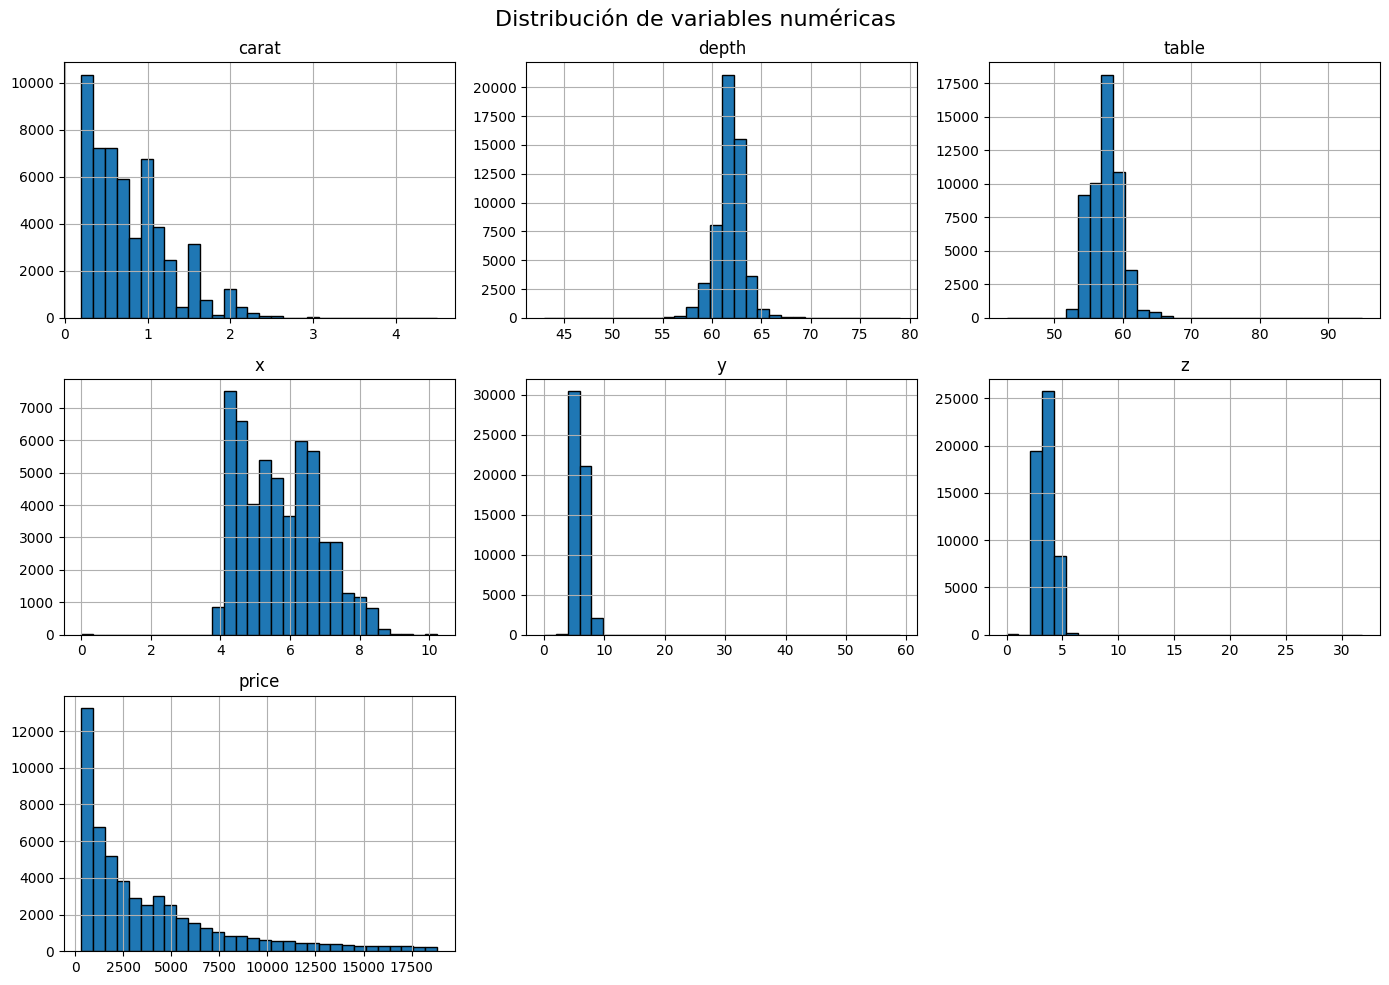


--- Boxplots de variables numéricas ---


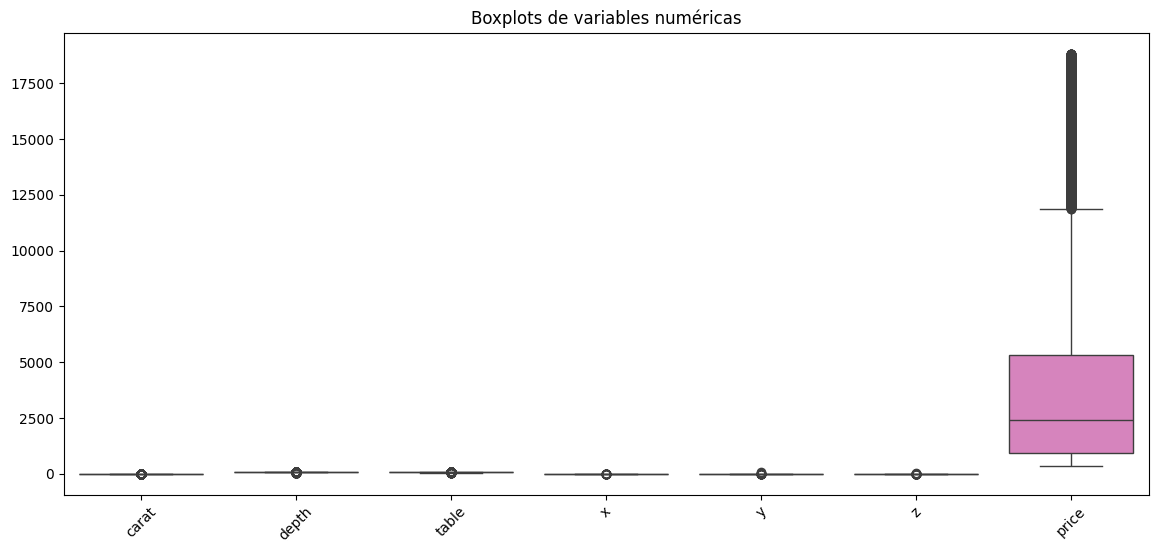


--- Diagramas de barras: variables categóricas ---


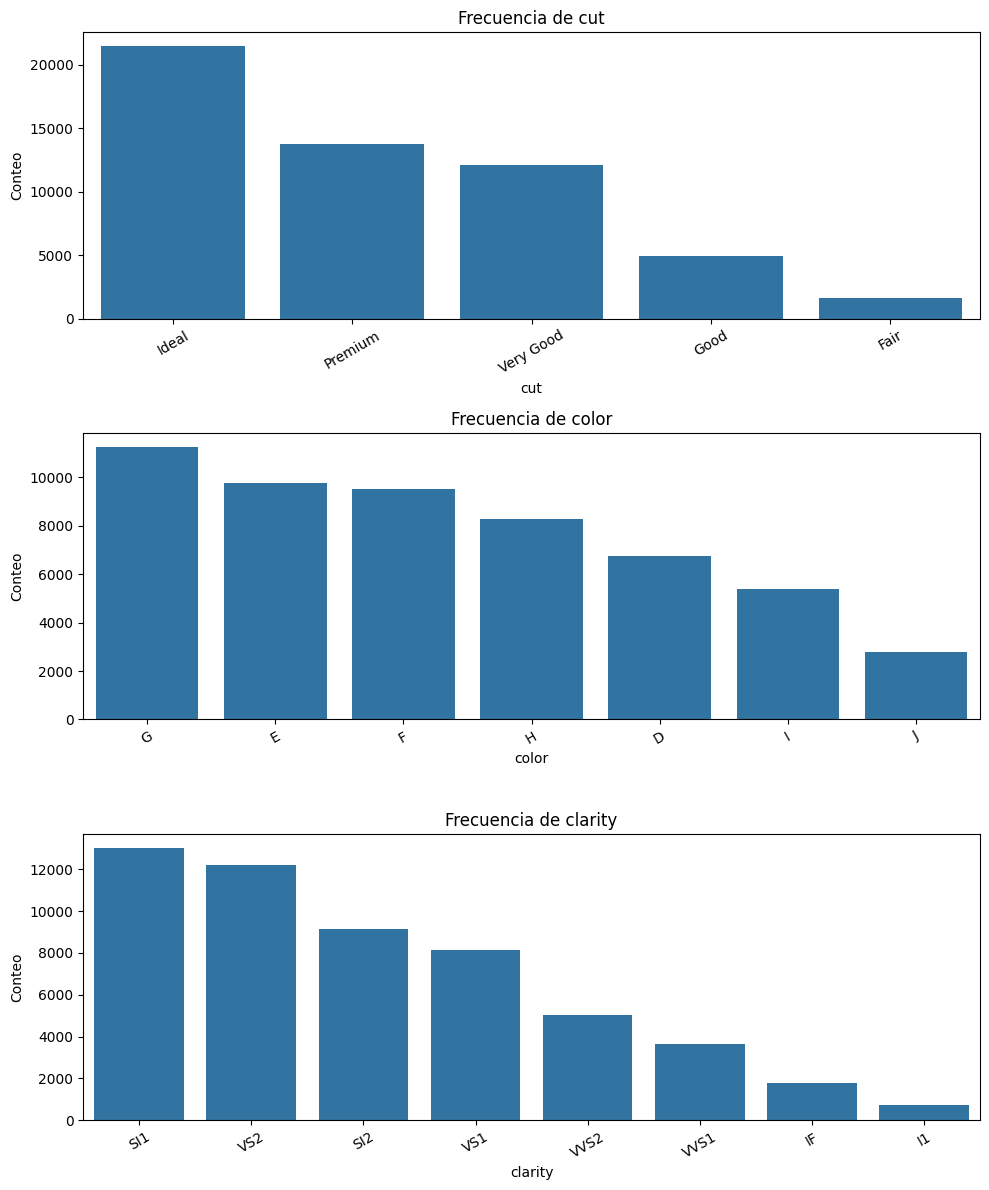

In [3]:
# === 1. Estadísticas descriptivas ===

# Variables numéricas
print("\n--- Estadísticas descriptivas: variables numéricas ---")
desc_num = diamonds_df.select_dtypes(include=[np.number]).describe().T
display(desc_num)

# Variables categóricas — tablas de frecuencia
print("\n--- Tablas de frecuencia: variables categóricas ---")
cat_cols = diamonds_df.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    print(f"\nFrecuencia de {col}:")
    freq_table = diamonds_df[col].value_counts().to_frame("frecuencia")
    freq_table["porcentaje (%)"] = (freq_table["frecuencia"] / len(diamonds_df) * 100).round(2)
    display(freq_table)

# === 2. Gráficos para variables numéricas ===

# Histogramas
print("\n--- Histogramas de variables numéricas ---")
diamonds_df.select_dtypes(include=[np.number]).hist(
    figsize=(14,10), bins=30, edgecolor='black'
)
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots (para ver dispersión y outliers)
print("\n--- Boxplots de variables numéricas ---")
plt.figure(figsize=(14,6))
sns.boxplot(data=diamonds_df.select_dtypes(include=[np.number]))
plt.title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.show()

# === 3. Gráficos para variables categóricas ===
print("\n--- Diagramas de barras: variables categóricas ---")

fig, axes = plt.subplots(nrows=len(cat_cols), ncols=1, figsize=(10, 4*len(cat_cols)))
if len(cat_cols) == 1:
    axes = [axes]  # por si solo hay una variable categórica

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=diamonds_df, x=col, ax=ax, order=diamonds_df[col].value_counts().index)
    ax.set_title(f"Frecuencia de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Conteo")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
* ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
* Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
* ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?

/tmp/ipython-input-4209781036.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


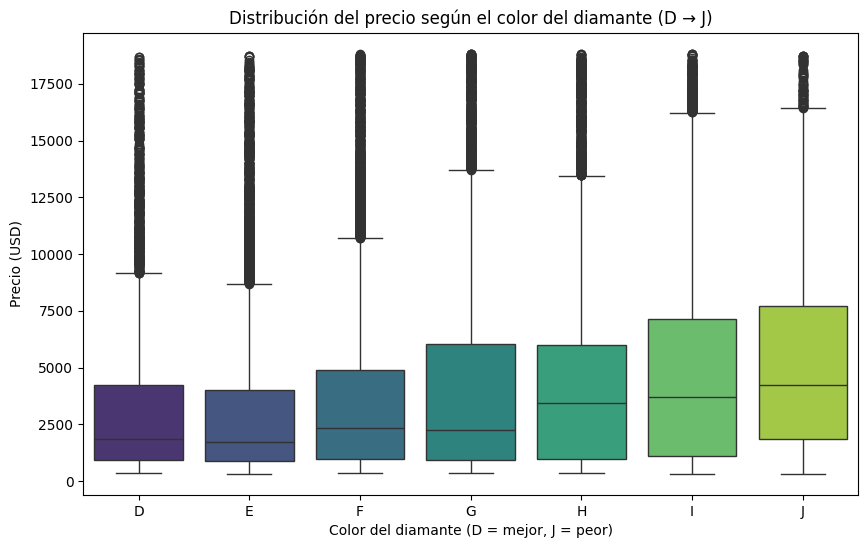

💬 Observaciones sobre el boxplot:

- En general, se espera que los diamantes con mejor color (D, E, F) tengan precios más altos.
- Sin embargo, puede que la tendencia no sea estrictamente descendente,
  porque el precio también depende fuertemente de otras variables,
  como el peso (carat) o la claridad (clarity).
- Por ejemplo, un diamante de color G pero con mayor carat puede costar más que uno de color D pequeño.
- Esto sugiere que el color no explica por sí solo las diferencias de precio.



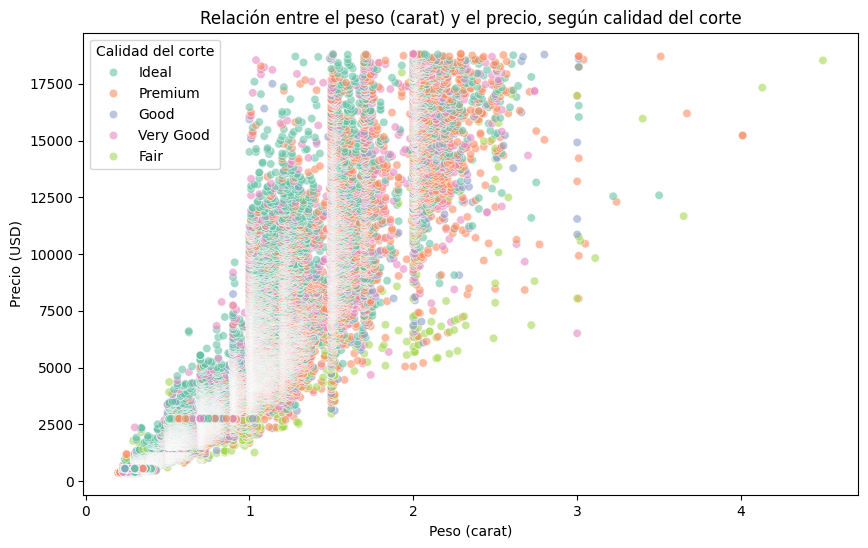

💬 Observaciones sobre el scatterplot:

- Se observa una relación claramente positiva entre el peso (carat) y el precio:
  a mayor carat, mayor precio.
- Los puntos están distribuidos de forma casi exponencial,
  mostrando que el precio crece más rápido conforme aumenta el tamaño del diamante.
- Además, los diamantes con mejor corte (Ideal, Premium)
  suelen ubicarse en rangos de precio más altos para un mismo carat.
- Esto indica que la calidad del corte también influye significativamente en el valor.



In [4]:
# Orden correcto de categorías de color (de mejor a peor)
color_order = ["D", "E", "F", "G", "H", "I", "J"]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=diamonds_df,
    x=pd.Categorical(diamonds_df["color"], categories=color_order, ordered=True),
    y="price",
    palette="viridis"
)
plt.title("Distribución del precio según el color del diamante (D → J)")
plt.xlabel("Color del diamante (D = mejor, J = peor)")
plt.ylabel("Precio (USD)")
plt.show()

print("💬 Observaciones sobre el boxplot:")
print("""
- En general, se espera que los diamantes con mejor color (D, E, F) tengan precios más altos.
- Sin embargo, puede que la tendencia no sea estrictamente descendente,
  porque el precio también depende fuertemente de otras variables,
  como el peso (carat) o la claridad (clarity).
- Por ejemplo, un diamante de color G pero con mayor carat puede costar más que uno de color D pequeño.
- Esto sugiere que el color no explica por sí solo las diferencias de precio.
""")


# === 2. Gráfico de dispersión: precio vs carat, coloreado por calidad del corte (cut) ===

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=diamonds_df,
    x="carat", y="price", hue="cut",
    alpha=0.6, palette="Set2"
)
plt.title("Relación entre el peso (carat) y el precio, según calidad del corte")
plt.xlabel("Peso (carat)")
plt.ylabel("Precio (USD)")
plt.legend(title="Calidad del corte")
plt.show()

print("💬 Observaciones sobre el scatterplot:")
print("""
- Se observa una relación claramente positiva entre el peso (carat) y el precio:
  a mayor carat, mayor precio.
- Los puntos están distribuidos de forma casi exponencial,
  mostrando que el precio crece más rápido conforme aumenta el tamaño del diamante.
- Además, los diamantes con mejor corte (Ideal, Premium)
  suelen ubicarse en rangos de precio más altos para un mismo carat.
- Esto indica que la calidad del corte también influye significativamente en el valor.
""")

4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
* Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.

=== PARES CON |CORRELACIÓN| > 0.9 (todas las variables numéricas) ===
     carat  ~  x           corr =  0.9753
         x  ~  y           corr =  0.9747
         x  ~  z           corr =  0.9707
     carat  ~  z           corr =  0.9536
         y  ~  z           corr =  0.9520
     carat  ~  y           corr =  0.9520
     carat  ~  price       corr =  0.9219


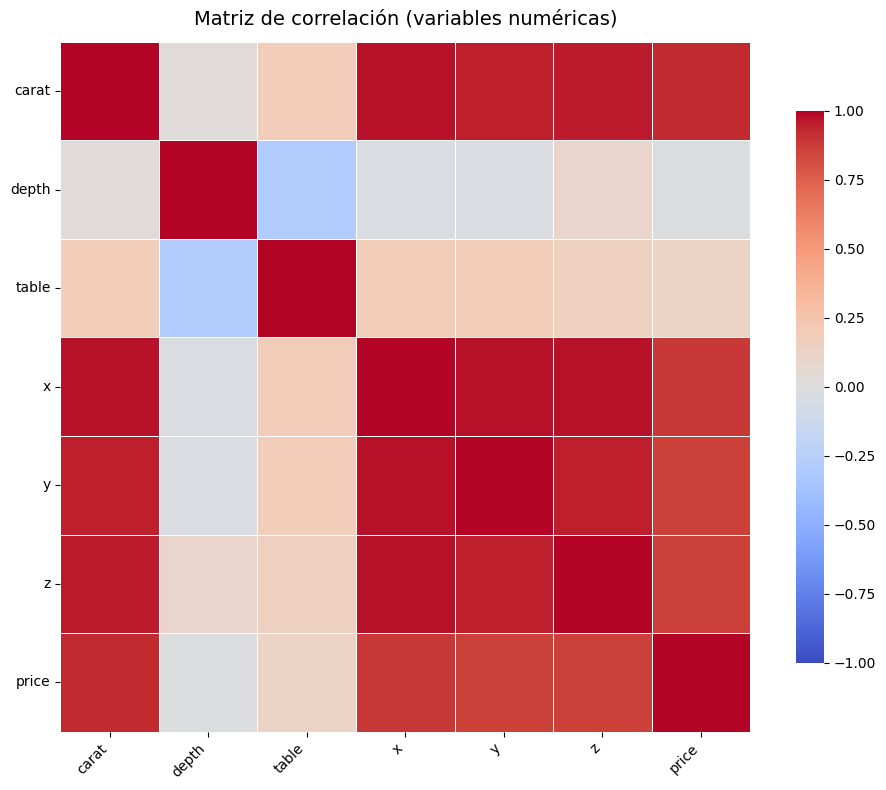


=== PARES DE PREDICTORES CON |CORRELACIÓN| > 0.9 (excluye 'price') ===
     carat  ~  x           corr =  0.9753
         x  ~  y           corr =  0.9747
         x  ~  z           corr =  0.9707
     carat  ~  z           corr =  0.9536
         y  ~  z           corr =  0.9520
     carat  ~  y           corr =  0.9520

=== Predictores eliminados por alta colinealidad (umbral = 0.9) ===
- DROP 'x' (corr ~ carat =  0.9753) -> mayor |corr| con price: carat(0.922) >= x(0.884)
- DROP 'z' (corr ~ carat =  0.9536) -> mayor |corr| con price: carat(0.922) >= z(0.861)
- DROP 'y' (corr ~ carat =  0.9520) -> mayor |corr| con price: carat(0.922) >= y(0.865)

Predictores finales (reducidos):
['carat', 'depth', 'table']

=== Verificación: pares con |correlación| > 0.9 tras la reducción ===
✅ No quedan predictores altamente correlacionados por encima del umbral.


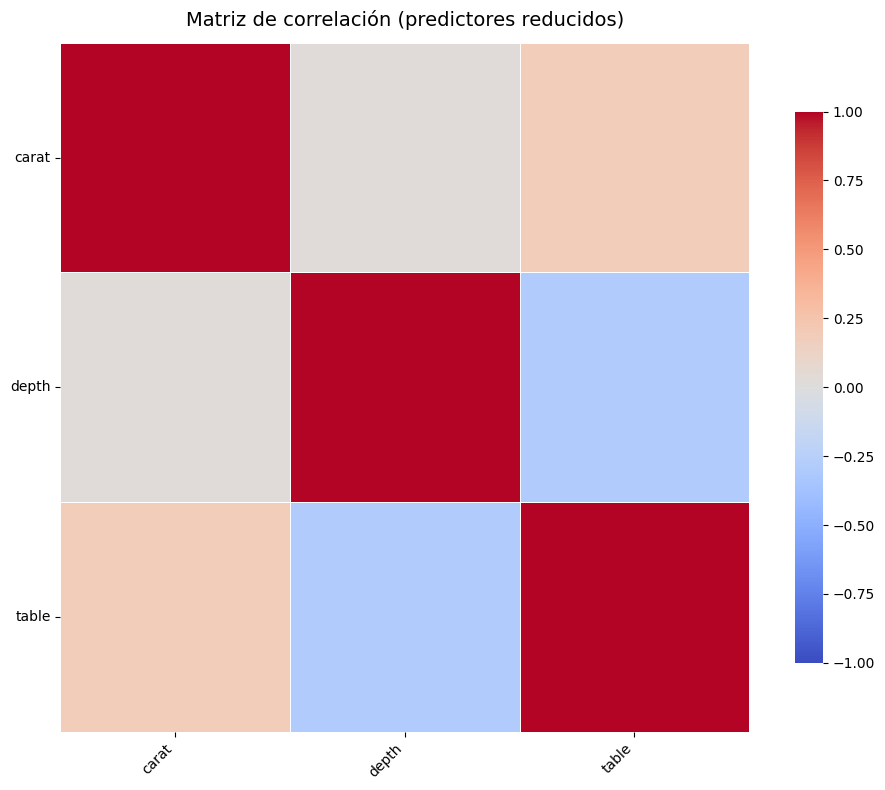

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

FILE_PATH = "diamonds_dataset.csv"
PRICE_COL = "price"
THRESHOLD = 0.90

def find_high_corr_pairs(corr_df: pd.DataFrame, threshold: float = 0.90):
    """
    Retorna lista de tuplas (var1, var2, corr) para pares con |corr| > threshold,
    ordenados por |corr| desc.
    """
    upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "var1", "level_1": "var2"})
    )
    pairs["abs_corr"] = pairs["corr"].abs()
    high = pairs[pairs["abs_corr"] > threshold].sort_values("abs_corr", ascending=False)
    return list(high[["var1", "var2", "corr"]].itertuples(index=False, name=None))

def plot_corr_heatmap(corr_df: pd.DataFrame, title: str, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_df,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        annot=False,
        square=True,
        cbar_kws={"shrink": 0.8},
        linewidths=0.5,
        linecolor="white"
    )
    plt.title(title, fontsize=14, pad=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

df = pd.read_csv(FILE_PATH)

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if not num_cols:
    raise ValueError("No se detectaron columnas numéricas en el dataset.")

corr_all = df[num_cols].corr(method="pearson")

print("=== PARES CON |CORRELACIÓN| > {0} (todas las variables numéricas) ===".format(THRESHOLD))
high_pairs_all = find_high_corr_pairs(corr_all, THRESHOLD)
if high_pairs_all:
    for a, b, c in high_pairs_all:
        print(f"{a:>10s}  ~  {b:<10s}  corr = {c: .4f}")
else:
    print("No se encontraron pares por encima del umbral.")

plot_corr_heatmap(corr_all, "Matriz de correlación (variables numéricas)")

predictors = [c for c in num_cols if c != PRICE_COL]
if not predictors:
    raise ValueError("No hay predictores numéricos (todas las columnas numéricas son 'price').")

corr_pred = df[predictors].corr(method="pearson")

target_corr = None
if PRICE_COL in df.columns and pd.api.types.is_numeric_dtype(df[PRICE_COL]):
    target_corr = df[predictors].corrwith(df[PRICE_COL]).abs()

print("\n=== PARES DE PREDICTORES CON |CORRELACIÓN| > {0} (excluye 'price') ===".format(THRESHOLD))
high_pairs_pred = find_high_corr_pairs(corr_pred, THRESHOLD)
if high_pairs_pred:
    for a, b, c in high_pairs_pred:
        print(f"{a:>10s}  ~  {b:<10s}  corr = {c: .4f}")
else:
    print("No se encontraron pares de predictores por encima del umbral.")

mean_abs_corr_pred = corr_pred.abs().mean()
to_drop = set()
kept = set(predictors)

pairs_sorted = sorted(high_pairs_pred, key=lambda t: abs(t[2]), reverse=True)

decisions = []

for a, b, c in pairs_sorted:
    if a in kept and b in kept:

        score_a = target_corr[a] if target_corr is not None and not pd.isna(target_corr[a]) else np.nan
        score_b = target_corr[b] if target_corr is not None and not pd.isna(target_corr[b]) else np.nan

        if np.isnan(score_a) and np.isnan(score_b):

            red_a = mean_abs_corr_pred[a]
            red_b = mean_abs_corr_pred[b]

            if red_a <= red_b:
                drop_var, keep_var = b, a
                reason = f"empate/NaN con target; menor redundancia promedio: {a}({red_a:.3f}) vs {b}({red_b:.3f})"
            else:
                drop_var, keep_var = a, b
                reason = f"empate/NaN con target; menor redundancia promedio: {b}({red_b:.3f}) vs {a}({red_a:.3f})"
        else:

            val_a = 0.0 if np.isnan(score_a) else float(score_a)
            val_b = 0.0 if np.isnan(score_b) else float(score_b)
            if val_a >= val_b:
                drop_var, keep_var = b, a
                reason = f"mayor |corr| con price: {a}({val_a:.3f}) >= {b}({val_b:.3f})"
            else:
                drop_var, keep_var = a, b
                reason = f"mayor |corr| con price: {b}({val_b:.3f}) > {a}({val_a:.3f})"

        kept.remove(drop_var)
        to_drop.add(drop_var)
        decisions.append((drop_var, keep_var, c, reason))

print("\n=== Predictores eliminados por alta colinealidad (umbral = {0}) ===".format(THRESHOLD))
if decisions:
    for drop_var, keep_var, corr_val, reason in decisions:
        print(f"- DROP '{drop_var}' (corr ~ {keep_var} = {corr_val: .4f}) -> {reason}")
else:
    print("No fue necesario eliminar predictores (no hay colinealidad alta entre predictores).")

reduced_predictors = sorted(list(kept))

print("\nPredictores finales (reducidos):")
print(reduced_predictors)

corr_reduced = df[reduced_predictors].corr(method="pearson")
print("\n=== Verificación: pares con |correlación| > {0} tras la reducción ===".format(THRESHOLD))
high_pairs_reduced = find_high_corr_pairs(corr_reduced, THRESHOLD)
if high_pairs_reduced:
    for a, b, c in high_pairs_reduced:
        print(f"{a:>10s}  ~  {b:<10s}  corr = {c: .4f}")
else:
    print("✅ No quedan predictores altamente correlacionados por encima del umbral.")

plot_corr_heatmap(corr_reduced, "Matriz de correlación (predictores reducidos)")

5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:
* Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
* Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (*Baseline*) y una columna para cada métrica.
* Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
> `price = intercepto + coeficiente × predictor`

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

FILE_PATH = "diamonds_dataset.csv"
df = pd.read_csv(FILE_PATH)

if "price" not in df.columns:
    raise ValueError("La columna 'price' no existe en el dataset.")
if not pd.api.types.is_numeric_dtype(df["price"]):
    raise TypeError("La columna 'price' debe ser numérica.")

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
predictor_candidates = [c for c in numeric_cols if c != "price"]

if not predictor_candidates:
    raise ValueError("No hay predictores numéricos disponibles (solo existe 'price').")

corr_series = df[predictor_candidates].corrwith(df["price"])
abs_corr_series = corr_series.abs()
best_predictor = abs_corr_series.idxmax()
best_corr_abs = abs_corr_series.loc[best_predictor]
best_corr_signed = corr_series.loc[best_predictor]

print("=== Selección de predictor ===")
print(f"Predictor elegido: {best_predictor}")
print(f"Correlación con 'price': {best_corr_signed:.6f} (|corr| = {best_corr_abs:.6f})\n")

work_df = df[[best_predictor, "price"]].dropna().copy()

X = work_df[[best_predictor]]
y = work_df["price"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

print("=== Partición de datos ===")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba       : {X_test.shape[0]} filas\n")

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = float(r2_score(y_test, y_pred))

results_df = pd.DataFrame([{
    "Model": "Baseline",
    "RMSE": rmse,
    "R2": r2
}])

print("=== Resultados en conjunto de prueba ===")
print(results_df.to_string(index=False), "\n")

intercept = float(linreg.intercept_)
coef = float(linreg.coef_[0])

print("=== Ecuación del modelo de regresión lineal simple ===")
print(f"price = {intercept:.6f} + {coef:.6f} × {best_predictor}")


=== Selección de predictor ===
Predictor elegido: carat
Correlación con 'price': 0.921886 (|corr| = 0.921886)

=== Partición de datos ===
Entrenamiento: 43148 filas
Prueba       : 10788 filas

=== Resultados en conjunto de prueba ===
   Model        RMSE       R2
Baseline 1551.591354 0.846662 

=== Ecuación del modelo de regresión lineal simple ===
price = -2271.386917 + 7783.966973 × carat


6. Utiliza todas las variables como predictoras para crear un segundo modelo:
* Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
* Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
* Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Ordinal_Robust*.

In [7]:
from sklearn.pipeline import Pipeline
X = df.drop(columns="price") #Separamos las columnas para el objetivo y entrenamiento
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(#Usamos la misma configuración que en el ejerecicio pasado
    X, y, test_size=0.20, random_state=1
)

Cat_cols = ["cut", "color", "clarity"] #Se separan las columnas categoricas y las numéricas
Num_cols = X.drop(columns=Cat_cols).columns.tolist()

#Se confirma el orden de las columnas categoricas
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

#Creamos el 'preprocessing'
preprocessing = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), Num_cols),
        ("cat", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), Cat_cols)
    ]
)

pipeline = Pipeline([ #De igual amnera se construye el pipeline
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

#Entrenamos el modelo
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
rmse = float(root_mean_squared_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

#Se crea df de resultados
resultados = pd.DataFrame({
    "Model": ["Ordinal_Robust"],
    "RMSE": rmse,
    "R2": r2
})

results_df = pd.concat([results_df, resultados], ignore_index=True)


print("\n=== Métricas en Test ===")
print(results_df.tail(1).to_string(index=False))

print("\n=== DataFrame de resultados actualizado ===")
display(results_df)


=== Métricas en Test ===
         Model        RMSE       R2
Ordinal_Robust 1230.229396 0.903602

=== DataFrame de resultados actualizado ===


,Model,RMSE,R2
0,Baseline,1551.591354,0.846662
1,Ordinal_Robust,1230.229396,0.903602


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.
* Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *OHE_MinMax*.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


if "price" not in df.columns:
    raise ValueError("La columna 'price' no existe en el dataset.")

y = df["price"].astype(float)
X = df.drop(columns=["price"])

mask = y.notna()
X, y = X.loc[mask], y.loc[mask]


num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols_all = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()


num_pipeline_minmax = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

cat_pipeline_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    ))
]) if len(cat_cols_all) > 0 else "drop"


preprocessing2 = ColumnTransformer(
    transformers=[
        ("num", num_pipeline_minmax, num_cols),
        ("cat", cat_pipeline_ohe, cat_cols_all),
    ],
    remainder="drop"
)

model2 = Pipeline(steps=[
    ("preprocessing2", preprocessing2),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)


model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

rmse2 = float(np.sqrt(mean_squared_error(y_test, y_pred2)))
r2_2 = float(r2_score(y_test, y_pred2))

try:
    results_df
except NameError:
    results_df = pd.DataFrame(columns=["Model", "RMSE", "R2"])

row2 = pd.DataFrame([{
    "Model": "OHE_MinMax",
    "RMSE": rmse2,
    "R2": r2_2
}])

results_df = pd.concat([results_df, row2], ignore_index=True)

print("=== Modelo: OHE_MinMax ===")
print(f"Columnas numéricas     : {num_cols}")
print(f"Columnas categóricas   : {cat_cols_all}")
print("\n=== Métricas en Test ===")
print(results_df.tail(1).to_string(index=False))

print("\n=== DataFrame de resultados actualizado ===")
display(results_df)

=== Modelo: OHE_MinMax ===
Columnas numéricas     : ['carat', 'depth', 'table', 'x', 'y', 'z']
Columnas categóricas   : ['cut', 'color', 'clarity']

=== Métricas en Test ===
     Model        RMSE      R2
OHE_MinMax 1128.118981 0.91894

=== DataFrame de resultados actualizado ===


,Model,RMSE,R2
0,Baseline,1551.591354,0.846662
1,Ordinal_Robust,1230.229396,0.903602
2,OHE_MinMax,1128.118981,0.918940


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *PolynomialDegree2*.

In [9]:

#Creamos el nuevo pipeline para la regresión polinomial
pipeline_poli = Pipeline([
    ("preprocessing2", preprocessing2),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

#Se repite el entrenamiento con la nueva regresión
pipeline_poli.fit(X_train, y_train)

y_pred_poli = pipeline_poli.predict(X_test)
rmse_poli = float(root_mean_squared_error(y_test, y_pred_poli))
r2_poli = float(r2_score(y_test, y_pred_poli))

# Crear DataFrame de resultados
resultados_poli = pd.DataFrame({
    "Model": ["PolynomialDegree2"],
    "RMSE": rmse_poli,
    "R2": r2_poli
})

results_df = pd.concat([results_df, resultados_poli], ignore_index=True)


print("\n=== Métricas en Test ===")
print(results_df.tail(1).to_string(index=False))

print("\n=== DataFrame de resultados actualizado ===")
display(results_df)

if results_df.loc[results_df["Model"] == "PolynomialDegree2", "R2"].values[0] > results_df.loc[results_df["Model"] == "OHE_MinMax", "R2"].values[0]:
  print("Al utilizar la regresión polinomial, el modelo mejoró")
else:
  print("\n\nNo se obtuvo un mejor modelo al utilizar la regresión polinomial")



=== Métricas en Test ===
            Model       RMSE       R2
PolynomialDegree2 658.386964 0.972391

=== DataFrame de resultados actualizado ===


,Model,RMSE,R2
0,Baseline,1551.591354,0.846662
1,Ordinal_Robust,1230.229396,0.903602
2,OHE_MinMax,1128.118981,0.918940
3,PolynomialDegree2,658.386964,0.972391


Al utilizar la regresión polinomial, el modelo mejoró


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.
* Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.

=== Modelos ordenados por R² ===


,Model,RMSE,R2
0,PolynomialDegree2,658.386964,0.972391
1,OHE_MinMax,1128.118981,0.918940
2,Ordinal_Robust,1230.229396,0.903602
3,Baseline,1551.591354,0.846662



 Mejor modelo según R²: PolynomialDegree2


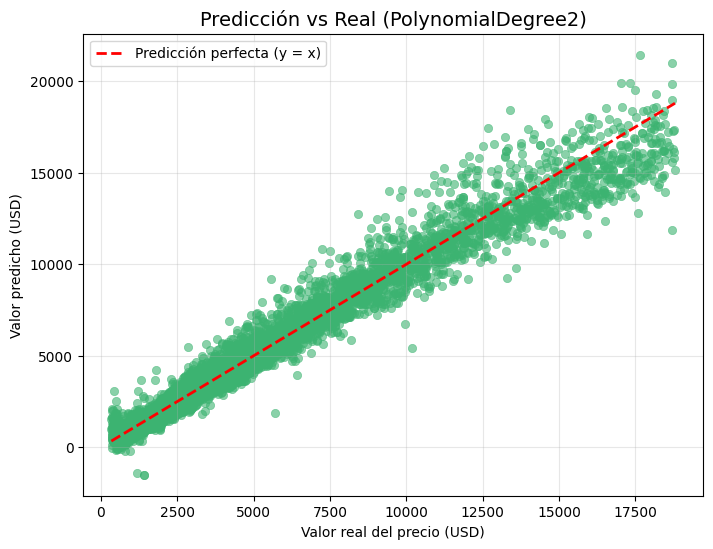

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ordenar resultados según R² (de mayor a menor)
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
print("=== Modelos ordenados por R² ===")
display(results_df)

# Seleccionar el mejor modelo (PolynomialDegree2)
best_model_name = results_df.loc[0, "Model"]
print(f"\n Mejor modelo según R²: {best_model_name}")

# Generar las predicciones reales vs predichas
y_pred_best = pipeline_poli.predict(X_test)

# Crear gráfico de dispersión
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color="mediumseagreen", edgecolor=None)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2, label="Predicción perfecta (y = x)")

plt.title(f"Predicción vs Real ({best_model_name})", fontsize=14)
plt.xlabel("Valor real del precio (USD)")
plt.ylabel("Valor predicho (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


El modelo PolynomialDegree2 presentó el mejor desempeño con un R² de 0.972 y un RMSE de 658.39, superando a los modelos lineales anteriores. En la gráfica de dispersión se observa que los valores predichos se alinean estrechamente con la línea de referencia (y = x), lo que indica un ajuste muy preciso. Esto demuestra que la regresión polinomial de segundo grado logró capturar relaciones no lineales entre las variables, mejorando significativamente la capacidad predictiva del modelo para estimar el precio de los diamantes.

10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.
* Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
* Extrae los nombres de las columnas polinómicas.
* Recupera los coeficientes y el intercepto del modelo de regresión lineal.
* Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.

Intercepto del modelo: 1277.8553
=== Top 10 variables más influyentes ===


,Feature,Coeficiente,Valor Absoluto
0,y z,1.839236e+06,1.839236e+06
1,carat y,1.262948e+06,1.262948e+06
2,x z,-6.863645e+05,6.863645e+05
3,y^2,-6.287373e+05,6.287373e+05
4,depth y,-3.234008e+05,3.234008e+05
5,table y,-2.743374e+05,2.743374e+05
6,carat z,2.525954e+05,2.525954e+05
7,y clarity_IF,-1.958954e+05,1.958954e+05
8,y clarity_VVS1,-1.887076e+05,1.887076e+05
9,carat x,-1.845378e+05,1.845378e+05


/tmp/ipython-input-589280672.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


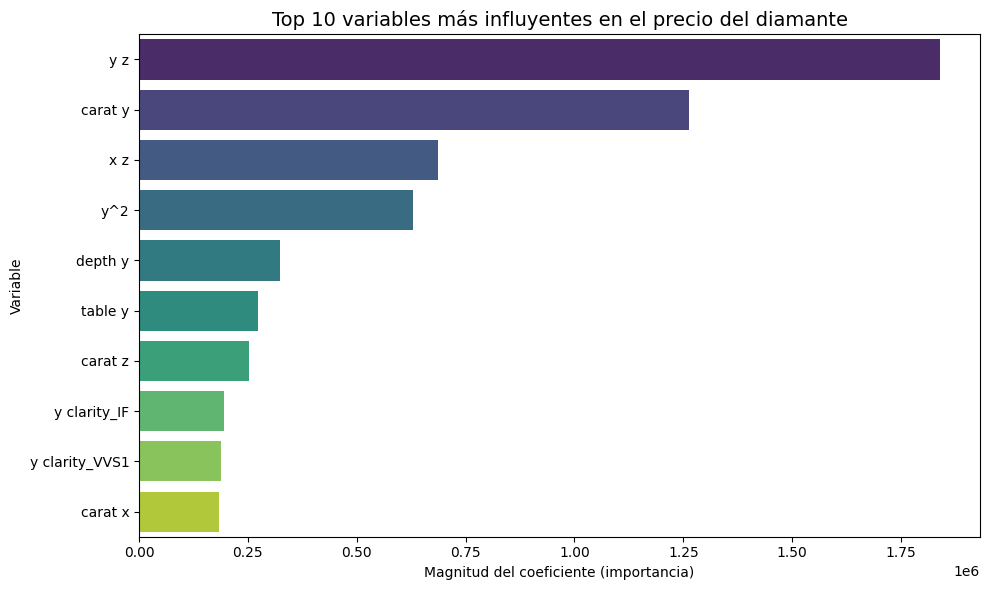

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import set_config

set_config(display="diagram")
pipeline_poli

# Nombres de columnas después del preprocesamiento (numéricas + dummies OHE)
preproc = pipeline_poli.named_steps["preprocessing2"]
onehot = preproc.named_transformers_["cat"].named_steps["onehot"]

num_features = list(num_cols)
cat_features = list(onehot.get_feature_names_out(cat_cols_all))
all_features = num_features + cat_features
len(all_features), all_features[:5]

# Nombres de columnas polinómicas a partir del transformador
poly_fitted = pipeline_poli.named_steps["poly"]
poly_feature_names = list(poly_fitted.get_feature_names_out(all_features))
len(poly_feature_names), poly_feature_names[:5]

# Coeficientes e intercepto del modelo lineal final
linreg = pipeline_poli.named_steps["regressor"]
coefs = linreg.coef_
intercepto = float(linreg.intercept_)

coef_df = (
    pd.DataFrame({
        "Feature": poly_feature_names,
        "Coeficiente": coefs,
        "Valor Absoluto": np.abs(coefs)
    })
    .sort_values("Valor Absoluto", ascending=False)
    .reset_index(drop=True)
)

print(f"Intercepto del modelo: {intercepto:.4f}")
print("=== Top 10 variables más influyentes ===")
display(coef_df.head(10))

# Top-10 por magnitud del coeficiente
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(10),
    x="Valor Absoluto", y="Feature", palette="viridis"
)
plt.title("Top 10 variables más influyentes en el precio del diamante", fontsize=14)
plt.xlabel("Magnitud del coeficiente (importancia)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


El análisis de los coeficientes del modelo PolynomialDegree2 revela que las variables más influyentes en el precio son las relacionadas con el peso (carat) y las dimensiones físicas (x, y, z) del diamante, especialmente sus interacciones como y×z, carat×y y x×z. En conjunto, el modelo confirma que tanto el tamaño como la calidad óptica determinan gran parte del precio final del diamante.